# Supplementary Material 2
[Article Title Here]

Submitted to: [Journal Name Here]

Jorge Lizarazo¹, Gustavo A. Londoño², Judit Ungvari Martin³ ⁴, Justin Baldwin⁵ & Scott K. Robinson⁶

¹ Center for Animals on the Move, Department of Biology, Western University, London, ON, Canada
² Department of Biological Sciences, Bioprocesses and Biotechnology, Icesi University, Cali, Colombia
³ Future Earth Global Secretariat, New York, NY, USA
⁴ Institute for a Sustainable Earth, George Mason University, Fairfax, VA, USA
⁵ Department of Ecology and Evolutionary Biology, University of California, Santa Cruz, USA
⁶ Florida Museum of Natural History, University of Florida, Gainesville, Florida, USA

Corresponding authors:

Jorge Lizarazo  Jorge.lizarazo.b@gmail.com &
Gustavo A. Londoño  galondono@icesi.edu.co

This notebook reconstructs the complete workflow used to integrate incubation events with environmental conditions and evaluate how ambient temperature and seasonal progression influence incubation behaviour. The analysis proceeds in four stages: data assembly, integration of environmental variables, event-level modelling, and daily behavioural aggregation.

In [175]:

import numpy as np ####
import xarray as xr  ####
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os
# dfrg
from datetime import datetime, time

## S2.1 Data Assembly and Event Reconstruction

Individual CSV files representing annotated incubation events were exported from the incubation detection pipeline. Each file corresponds to a single nest and contains behavioural events classified as:

• On bouts (active incubation)
• Off bouts (temporary nest absence)
• Nocturnal incubation intervals

For each event we retain the start and end timestamps, duration, nest temperature, and ambient temperature.

In this step all nest-level files are imported and concatenated into a single dataset. Temporal variables including calendar date and breeding month are derived from event start times.

In [176]:
new_one_path = 'dd/Finale'

all_data_frames = []

for filename in os.listdir(new_one_path):
    if '_analizado_finale.csv' in filename:
        df = pd.read_csv(os.path.join(new_one_path, filename))
        #df['End'] = pd.to_datetime(df['End'])

        df['Start'] = pd.to_datetime(df['Start'])
        df['End'] = pd.to_datetime(df['End'])

        df['Día'] = df['Start'].dt.date
        df['Month_Nest'] = df['Start'].dt.strftime('%B')

        nest_id = filename.replace('_analizado_finale.csv', '')
        df['Nest_ID'] = nest_id
        #df['Día'] = df['End'].dt.date
        #df['Month_Nest'] = df['End'].dt.strftime('%B')

        all_data_frames.append(df)

# Concatenando todas las DataFrames
final_df = pd.concat(all_data_frames, ignore_index=True)

# Reordenando las columnas
columns_order = ['Nest_ID', 'Día', 'Month_Nest', 'Tipo', 'Start', 'End', 'Duración (min)', 'Temperatura Promedio', 'Temperatura Ambiental Promedio']
final_df = final_df[columns_order]

# Si deseas guardar la DataFrame en un archivo CSV:
final = 'dd/Finale/data_finale'
final_df.to_csv(os.path.join(final, 'completo_data.csv'), index=False)

In [177]:
# Assuming 'Duración (min)' is the column with the duration in minutes
total_hours = final_df['Duración (min)'].sum() / 60
print(total_hours)

13516.25


In [178]:

florida = 'Clima/2005.csv'
florida6 = 'Clima/2006.csv'
# Read the CSV file into a DataFrame
fl = pd.read_csv(florida)
fl6 = pd.read_csv(florida6)

In [179]:
fl

,Station ID,Station Name,Date,Time,Soil Temp (C),Temp @ 60cm (C),Temp @ 2m (C),Temp @ 10m (C),Relative Humidity (%),Dew Point Temp (C),Rainfall Amount (in),Wind Speed (mph),Wind Direction (deg),Solar Radiation (w/m2)
0,260,ALACHUA,01/01/2005,0:00:00,14.09,10.67,11.46,13.35,95.1,10.70,0.0,5.51,62.40,0.40
1,260,ALACHUA,01/01/2005,0:15:00,14.06,11.48,11.86,13.16,95.6,11.18,0.0,2.52,62.09,0.40
2,260,ALACHUA,01/01/2005,0:30:00,14.03,10.86,11.52,13.10,95.4,10.81,0.0,2.34,70.10,0.40
3,260,ALACHUA,01/01/2005,0:45:00,13.99,10.44,11.05,12.96,95.4,10.34,0.0,2.78,64.86,0.40
4,260,ALACHUA,01/01/2005,1:00:00,13.96,10.51,11.06,12.87,95.8,10.41,0.0,2.64,84.70,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,260,ALACHUA,12/31/2005,22:45:00,15.10,18.78,18.31,18.89,91.0,16.81,0.0,9.37,225.20,2.46
35036,260,ALACHUA,12/31/2005,23:00:00,15.11,18.78,18.24,18.87,90.7,16.69,0.0,12.44,217.20,2.45
35037,260,ALACHUA,12/31/2005,23:15:00,15.12,18.64,18.18,18.75,90.7,16.63,0.0,9.30,218.90,2.42
35038,260,ALACHUA,12/31/2005,23:30:00,15.13,18.39,17.91,18.46,91.3,16.47,0.0,10.03,244.70,2.37


In [180]:
unique_values = np.unique(fl['Rainfall Amount (in)'])
print(unique_values)

[0.         0.00354331 0.00748031 0.00984252 0.01023622 0.01102362
 0.01496063 0.01850394 0.02007874 0.02244094 0.02598425 0.02992126
 0.03503937 0.04015748 0.05       0.05984252 0.07007874 0.07992126
 0.09015748 0.1        0.10984252 0.12007874 0.12992126 0.14015748
 0.15       0.15984252 0.17007874 0.19015748 0.2        0.20984252
 0.22007874 0.22992126 0.24015748 0.25       0.25984252 0.27007874
 0.27992126 0.3        0.30984252 0.32007874 0.32992126 0.34015748
 0.35       0.35984252 0.37007874 0.37992126 0.39015748 0.4
 0.40984252 0.42007874 0.42992126 0.45       0.45984252 0.47992126
 0.50984252 0.52007874 0.54015748 0.55984252 0.6        0.62007874
 0.64015748 0.7        0.77007874 0.79015748 0.89015748 0.92007874
 0.95       1.02992126]


In [181]:
fl6

,Station ID,Station Name,Date,Time,Soil Temp (C),Temp @ 60cm (C),Temp @ 2m (C),Temp @ 10m (C),Relative Humidity (%),Dew Point Temp (C),Rainfall Amount (in),Wind Speed (mph),Wind Direction (deg),Solar Radiation (w/m2)
0,260,ALACHUA,01/01/2006,0:00:00,15.14,18.01,17.50,18.10,92.5,16.27,0.0,10.65,215.9,2.26
1,260,ALACHUA,01/01/2006,0:15:00,15.15,17.96,17.57,17.97,93.1,16.44,0.0,8.56,237.3,2.26
2,260,ALACHUA,01/01/2006,0:30:00,15.15,17.92,17.43,17.93,93.4,16.35,0.0,7.12,237.4,2.25
3,260,ALACHUA,01/01/2006,0:45:00,15.16,17.89,17.37,17.88,93.5,16.31,0.0,9.70,244.8,2.26
4,260,ALACHUA,01/01/2006,1:00:00,15.17,17.81,17.30,17.80,93.6,16.26,0.0,7.84,246.2,2.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,260,ALACHUA,12/31/2006,22:45:00,19.59,21.88,21.51,21.96,76.9,17.28,0.0,13.20,135.8,0.40
35036,260,ALACHUA,12/31/2006,23:00:00,19.58,21.73,21.36,21.82,77.7,17.30,0.0,11.70,143.1,0.40
35037,260,ALACHUA,12/31/2006,23:15:00,19.56,21.76,21.39,21.88,77.5,17.29,0.0,13.89,151.3,0.40
35038,260,ALACHUA,12/31/2006,23:30:00,19.55,21.72,21.37,21.83,77.6,17.29,0.0,8.59,162.5,0.40


In [182]:
final_df.head(3)

,Nest_ID,Día,Month_Nest,Tipo,Start,End,Duración (min),Temperatura Promedio,Temperatura Ambiental Promedio
0,Mimus_polyglottos_ALS107_06,2006-07-08,July,Nocturnal,2006-07-08 18:58:00,2006-07-08 20:48:00,110.0,32.214054,27.371351
1,Mimus_polyglottos_ALS107_06,2006-07-08,July,Off,2006-07-08 20:48:00,2006-07-08 20:55:00,7.0,27.240000,25.822500
2,Mimus_polyglottos_ALS107_06,2006-07-08,July,Nocturnal,2006-07-08 20:55:00,2006-07-09 06:42:00,587.0,29.581922,21.432262


In [183]:
final_df.isna().sum()

Nest_ID                           0
Día                               0
Month_Nest                        0
Tipo                              0
Start                             0
End                               0
Duración (min)                    0
Temperatura Promedio              0
Temperatura Ambiental Promedio    0
dtype: int64

## S2.2 Integration of Environmental Conditions

To evaluate environmental drivers of incubation behaviour, meteorological observations were integrated with the behavioural event dataset.

Climate records include rainfall, humidity, soil temperature, air temperature at multiple heights, and dew point temperature.

Environmental variables were matched to each incubation event using the following rules:

• For short events (≤15 minutes), the nearest climate observation was used
• For longer events, all climate records within the event interval were extracted

Rainfall values were summed across the interval, while other environmental variables were averaged.

This produces an event-level dataset linking behavioural events with concurrent environmental conditions.


In [184]:
fl_all = pd.concat([fl, fl6], ignore_index=True)
final_df['Start'] = pd.to_datetime(final_df['Start'])
final_df['End'] = pd.to_datetime(final_df['End'])
fl_all['Datetime'] = pd.to_datetime(fl_all['Date'] + ' ' + fl_all['Time'])


final_df_copy = final_df.copy()


cols_to_avg = ['Relative Humidity (%)', 'Soil Temp (C)', 'Temp @ 60cm (C)',
               'Temp @ 2m (C)', 'Temp @ 10m (C)', 'Dew Point Temp (C)']


for idx, row in final_df.iterrows():
    if (row['End'] - row['Start']).seconds / 60 <= 15:  # Intervalo de menos de o igual a 15 minutos
        closest_index = fl_all['Datetime'].sub(row['Start']).abs().idxmin()
        rain_value = fl_all.at[closest_index, 'Rainfall Amount (in)']
        final_df_copy.at[idx, 'Rainfall Amount (in)_sum'] = rain_value
        subset = fl_all.iloc[[closest_index]]
    else:
        mask = (fl_all['Datetime'] >= row['Start']) & (fl_all['Datetime'] <= row['End'])
        subset = fl_all[mask]
        rain_sum = subset['Rainfall Amount (in)'].sum()
        final_df_copy.at[idx, 'Rainfall Amount (in)_sum'] = rain_sum

    avg_values = subset[cols_to_avg].mean()

    for col in cols_to_avg:
        final_df_copy.at[idx, col + '_avg'] = avg_values[col]

In [185]:

output_path = 'dd/Finale/data_finale/Completo_Ambiental_Data.csv'

# Guarda el DataFrame en un archivo CSV
final_df_copy.to_csv(output_path, index=False)

In [186]:
final_df_copy.head(5)

,Nest_ID,Día,Month_Nest,Tipo,Start,End,Duración (min),Temperatura Promedio,Temperatura Ambiental Promedio,Rainfall Amount (in)_sum,Relative Humidity (%)_avg,Soil Temp (C)_avg,Temp @ 60cm (C)_avg,Temp @ 2m (C)_avg,Temp @ 10m (C)_avg,Dew Point Temp (C)_avg
0,Mimus_polyglottos_ALS107_06,2006-07-08,July,Nocturnal,2006-07-08 18:58:00,2006-07-08 20:48:00,110.0,32.214054,27.371351,0.0,62.635000,28.437500,24.412500,24.547500,25.231250,16.911250
1,Mimus_polyglottos_ALS107_06,2006-07-08,July,Off,2006-07-08 20:48:00,2006-07-08 20:55:00,7.0,27.240000,25.822500,0.0,68.360000,28.210000,22.380000,22.980000,23.940000,16.830000
2,Mimus_polyglottos_ALS107_06,2006-07-08,July,Nocturnal,2006-07-08 20:55:00,2006-07-09 06:42:00,587.0,29.581922,21.432262,0.0,89.438462,26.715641,16.149744,16.468205,17.878974,14.655641
3,Mimus_polyglottos_ALS107_06,2006-07-09,July,Off,2006-07-09 06:42:00,2006-07-09 06:50:00,8.0,22.980000,18.397778,0.0,94.800000,25.360000,16.460000,15.390000,17.300000,14.560000
4,Mimus_polyglottos_ALS107_06,2006-07-09,July,On,2006-07-09 06:50:00,2006-07-09 07:15:00,25.0,28.857692,18.582308,0.0,94.300000,25.290000,18.280000,17.260000,18.185000,16.335000


In [187]:
nan_count = final_df_copy.isna().sum()
print(nan_count)

Nest_ID                           0
Día                               0
Month_Nest                        0
Tipo                              0
Start                             0
End                               0
Duración (min)                    0
Temperatura Promedio              0
Temperatura Ambiental Promedio    0
Rainfall Amount (in)_sum          0
Relative Humidity (%)_avg         0
Soil Temp (C)_avg                 0
Temp @ 60cm (C)_avg               0
Temp @ 2m (C)_avg                 0
Temp @ 10m (C)_avg                0
Dew Point Temp (C)_avg            0
dtype: int64


In [188]:
final_df_copy["Start"] = pd.to_datetime(final_df_copy["Start"])
final_df_copy["Day_of_Year"] = final_df_copy["Start"].dt.dayofyear

In [189]:
df_on = final_df_copy[final_df_copy['Tipo'] == 'On']
df_off = final_df_copy[final_df_copy['Tipo'] == 'Off']
df_nocturnal = final_df_copy[final_df_copy['Tipo'] == 'Nocturnal']

In [190]:
df_on

,Nest_ID,Día,Month_Nest,Tipo,Start,End,Duración (min),Temperatura Promedio,Temperatura Ambiental Promedio,Rainfall Amount (in)_sum,Relative Humidity (%)_avg,Soil Temp (C)_avg,Temp @ 60cm (C)_avg,Temp @ 2m (C)_avg,Temp @ 10m (C)_avg,Dew Point Temp (C)_avg,Day_of_Year
4,Mimus_polyglottos_ALS107_06,2006-07-09,July,On,2006-07-09 06:50:00,2006-07-09 07:15:00,25.0,28.857692,18.582308,0.0,94.300000,25.290000,18.280000,17.260,18.185000,16.335,190
6,Mimus_polyglottos_ALS107_06,2006-07-09,July,On,2006-07-09 07:19:00,2006-07-09 08:13:00,54.0,29.029091,20.650909,0.0,84.433333,25.193333,21.156667,20.180,20.773333,17.270,190
8,Mimus_polyglottos_ALS107_06,2006-07-09,July,On,2006-07-09 08:18:00,2006-07-09 08:40:00,22.0,30.595652,23.954348,0.0,75.000000,25.150000,23.920000,22.680,22.900000,17.210,190
10,Mimus_polyglottos_ALS107_06,2006-07-09,July,On,2006-07-09 08:47:00,2006-07-09 08:57:00,10.0,31.179091,25.559091,0.0,71.700000,25.160000,24.890000,23.550,23.650000,17.490,190
12,Mimus_polyglottos_ALS107_06,2006-07-09,July,On,2006-07-09 09:03:00,2006-07-09 09:25:00,22.0,32.747391,26.206957,0.0,68.420000,25.220000,26.280000,24.900,24.840000,17.140,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30600,M_Polyglottos___MP1_06,2006-04-22,April,On,2006-04-22 17:46:00,2006-04-22 18:16:00,30.0,29.445484,22.340645,0.0,78.200000,23.210000,22.405000,22.155,22.690000,18.170,112
30602,M_Polyglottos___MP1_06,2006-04-22,April,On,2006-04-22 18:21:00,2006-04-22 18:32:00,11.0,29.780833,21.670833,0.0,79.300000,23.220000,22.260000,21.990,22.540000,18.230,112
30604,M_Polyglottos___MP1_06,2006-04-22,April,On,2006-04-22 18:39:00,2006-04-22 19:00:00,21.0,29.914091,21.600000,0.0,83.950000,23.205000,21.745000,21.530,22.145000,18.695,112
30606,M_Polyglottos___MP1_06,2006-04-22,April,On,2006-04-22 19:09:00,2006-04-22 19:13:00,4.0,27.856000,21.600000,0.0,85.500000,23.180000,21.390000,21.280,22.000000,18.740,112


In [191]:
df_off.columns

Index(['Nest_ID', 'Día', 'Month_Nest', 'Tipo', 'Start', 'End',
       'Duración (min)', 'Temperatura Promedio',
       'Temperatura Ambiental Promedio', 'Rainfall Amount (in)_sum',
       'Relative Humidity (%)_avg', 'Soil Temp (C)_avg', 'Temp @ 60cm (C)_avg',
       'Temp @ 2m (C)_avg', 'Temp @ 10m (C)_avg', 'Dew Point Temp (C)_avg',
       'Day_of_Year'],
      dtype='object')

## S2.3 Event-Level Behavioural Exploration

Exploratory analyses were conducted to visualize relationships among behavioural and environmental variables.

Pairwise relationships were examined separately for:

• On bouts
• Off bouts
• Nocturnal incubation events

These visualizations help identify potential correlations and guide the formulation of statistical models.

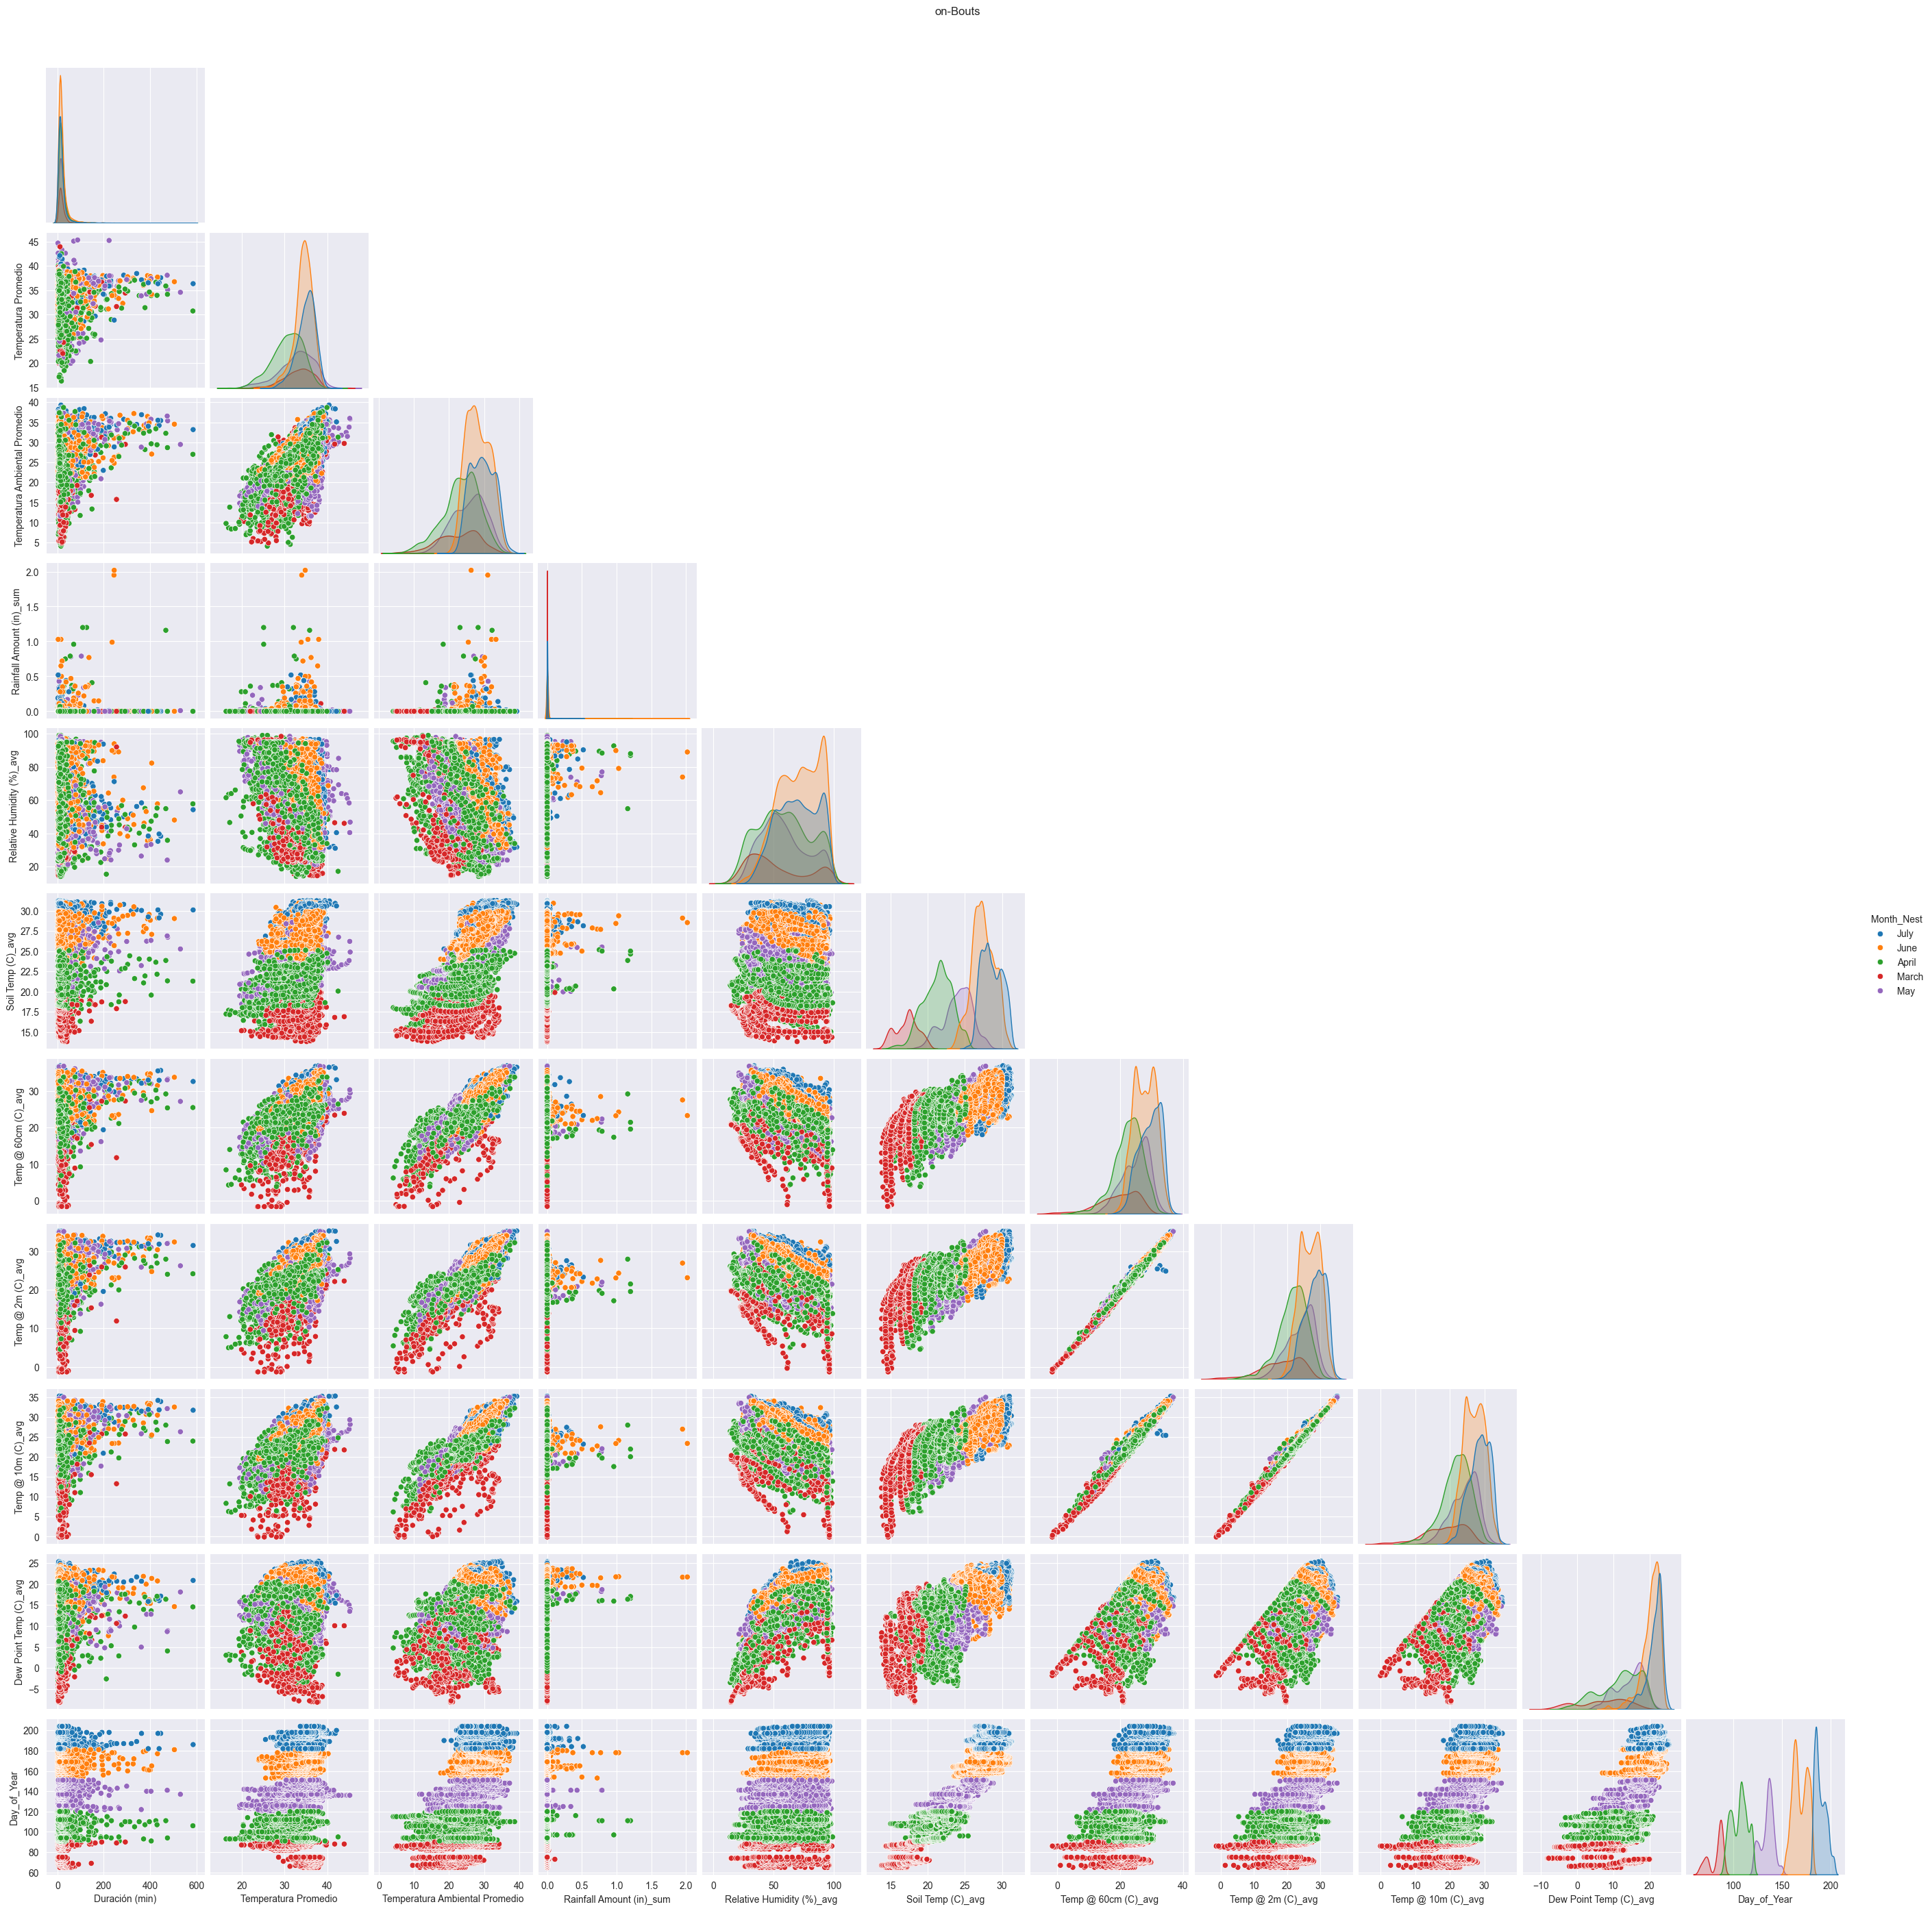

In [192]:
df_cleaned = df_on.dropna()
numeric_df = df_on.select_dtypes(include=[float, int])

sns.pairplot(df_on, vars=numeric_df.columns, hue='Month_Nest', corner=True, palette="tab10")
plt.suptitle("on-Bouts", y=1.02)
plt.show()

In [ ]:
df_cleaned = df_off.dropna()
numeric_df = df_off.select_dtypes(include=[float, int])

sns.pairplot(df_off, vars=numeric_df.columns, hue='Month_Nest', corner=True, palette="tab10")
plt.suptitle("Off-Bouts", y=1.02)
plt.show()

In [ ]:
df_cleaned = df_nocturnal.dropna()
numeric_df = df_nocturnal.select_dtypes(include=[float, int])

sns.pairplot(df_nocturnal, vars=numeric_df.columns, hue='Month_Nest', corner=True, palette="tab10")
plt.suptitle("df_nocturnal", y=1.02)
plt.show()

In [ ]:
print(df_on.columns)

## S2.4 Mixed-Effects Models of Bout Duration

Incubation events are nested within nests, producing repeated observations per individual nest. To account for this hierarchical structure, mixed-effects models were used with nest identity as a random intercept.

On-bout duration was log-transformed to stabilize variance and modelled as a function of ambient temperature measured at 60 cm above ground.

Residual diagnostics were performed to detect extreme observations, which were flagged but retained for visualization.

In [ ]:
from pygam import GammaGAM, s


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
df_on = final_df_copy[final_df_copy["Tipo"] == "On"].copy()

df_on = df_on.dropna(subset=[
    "Duración (min)",
    "Temp @ 60cm (C)_avg",
    "Nest_ID"
])
df_on["log_on"] = np.log(df_on['Duración (min)'])

In [ ]:
model_on = smf.mixedlm(
    'log_on ~ Q("Temp @ 60cm (C)_avg")',
    data=df_on,
    groups=df_on["Nest_ID"]
).fit()

print(model_on.summary())

In [ ]:
#X_raw = df_on[['Temp @ 60cm (C)_avg']]
#y = df_on['Duración (min)']

#X_model = sm.add_constant(X_raw)

#glm_linear_on = sm.GLM(
#    y,
#    X_model,
#    family=sm.families.Gaussian()
#).fit(cov_type="HC3")

In [ ]:
#print(glm_linear_on.summary())

In [ ]:
# residuals from mixed model
residuals = df_on["log_on"] - model_on.fittedvalues

# standard deviation threshold
std_dev = np.std(residuals)
outlier_threshold = 2 * std_dev

# identify outliers
outlier_indices = np.where(np.abs(residuals) > outlier_threshold)[0]

# limit to max 5%
max_outliers = int(0.05 * len(df_on))
if len(outlier_indices) > max_outliers:
    sorted_idx = np.argsort(np.abs(residuals))
    outlier_indices = sorted_idx[-max_outliers:]

In [ ]:
temp_range = np.linspace(
    df_on['Temp @ 60cm (C)_avg'].min(),
    df_on['Temp @ 60cm (C)_avg'].max(),
    300
)

season_points = [
    df_on['Day_of_Year'].quantile(0.25),
    df_on['Day_of_Year'].quantile(0.50),
    df_on['Day_of_Year'].quantile(0.75)
]

pred_list = []

for doy in season_points:
    for t in temp_range:
        pred_list.append([t, doy])

pred_df = pd.DataFrame(
    pred_list,
    columns=['Temp @ 60cm (C)_avg', 'Day_of_Year']
)

pred_df["log_pred"] = model_on.predict(pred_df)
pred_df["pred_minutes"] = np.exp(pred_df["log_pred"])

In [ ]:
fig, ax = plt.subplots(figsize=(3, 2), dpi=300)

X_raw = df_on[['Temp @ 60cm (C)_avg']]
y = df_on['Duración (min)']

# All data
plt.scatter(
    X_raw,
    y,
    color='#888B91',
    s=2,
    alpha=0.05,
    label='Data'
)

# Outliers
X_outliers = X_raw.iloc[outlier_indices]
y_outliers = y.iloc[outlier_indices]

plt.scatter(
    X_outliers,
    y_outliers,
    color='#95C2F5',
    s=2,
    alpha=0.3,
    label='Outliers'
)

# Prediction line
plt.plot(
    pred_df['Temp @ 60cm (C)_avg'],
    pred_df['pred_minutes'],
    color='#888B91',
    linewidth=1.5,
    label='Mixed model prediction'
)


# Force axis elements to black
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')



plt.xlabel('Temperature at 60cm avg (C)', fontsize=9)
plt.ylabel('On-bout Duration (min)', fontsize=9)

plt.tight_layout()

plt.savefig(
    'Figures/Temper_ON_MixedModel.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Total observations
n_total_on = len(y)

# Number of detected extreme residuals
n_outliers_on = len(outlier_indices)

# Percentage
percent_outliers_on = (n_outliers_on / n_total_on) * 100

print("\nON-bout model residual diagnostics")
print(f"Total observations: {n_total_on}")
print(f"Extreme residuals detected: {n_outliers_on}")
print(f"Percentage of extreme observations: {percent_outliers_on:.2f}%")

## S2.5 Seasonal Variation in Off-Bout Behaviour

To examine whether temperature responses change across the breeding season, Off-bout duration was modelled as a function of temperature, breeding month, and their interaction.

This allows testing whether the relationship between ambient temperature and incubation recess duration varies between early and late breeding periods.

In [ ]:
df_off["log_off"] = np.log(df_off['Duración (min)'])

model_off = smf.mixedlm(
    'log_off ~ Q("Temp @ 60cm (C)_avg")',
    data=df_off,
    groups=df_off["Nest_ID"]
).fit()



In [ ]:
print(model_off.summary())

In [ ]:
y_log = df_off["log_off"]
fitted_log = model_off.fittedvalues

residuals = y_log - fitted_log

std_dev = np.std(residuals)
threshold = 2 * std_dev

outlier_indices = np.where(np.abs(residuals) > threshold)[0]

max_outliers = int(0.05 * len(residuals))
if len(outlier_indices) > max_outliers:
    sorted_idx = np.argsort(np.abs(residuals))
    outlier_indices = sorted_idx[-max_outliers:]

In [ ]:
temp_range = np.linspace(
    df_off['Temp @ 60cm (C)_avg'].min(),
    df_off['Temp @ 60cm (C)_avg'].max(),
    500
)

pred_df = pd.DataFrame({
    'Temp @ 60cm (C)_avg': temp_range
})

# predict log duration
pred_df["log_pred"] = model_off.predict(pred_df)

# convert back to minutes
pred_df["pred_minutes"] = np.exp(pred_df["log_pred"])


In [ ]:
fig, ax = plt.subplots(figsize=(3,2), dpi=300)

X_raw = df_off[['Temp @ 60cm (C)_avg']]
y = df_off['Duración (min)']

plt.scatter(
    X_raw,
    y,
    color='#888B91',
    s=2,
    alpha=0.05
)

X_outliers = X_raw.iloc[outlier_indices]
y_outliers = y.iloc[outlier_indices]

plt.scatter(
    X_outliers,
    y_outliers,
    color='#95C2F5',
    s=2,
    alpha=0.3
)

plt.plot(
    pred_df['Temp @ 60cm (C)_avg'],
    pred_df['pred_minutes'],
    color='#888B91',
    linewidth=1.5
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')

ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')



ax.set_ylim(0,200)

plt.xlabel('Temperature at 60cm avg (C)', fontsize=9)
plt.ylabel('Off-bout Duration (min)', fontsize=9)

plt.tight_layout()
plt.savefig('Figures/Temper_OFF_MixedModel.png', dpi=300,
            transparent=True, bbox_inches='tight')

plt.show()

In [ ]:
n_total_off = len(y)
n_outliers_off = len(outlier_indices)
percent_outliers_off = (n_outliers_off / n_total_off) * 100

print("\nOFF model:")
print(f"Total observations: {n_total_off}")
print(f"Extreme residuals detected: {n_outliers_off}")
print(f"Percentage: {percent_outliers_off:.2f}%")

In [ ]:
import statsmodels.formula.api as smf


In [ ]:
mixed_on = smf.mixedlm(
    'Q("Duración (min)") ~ Q("Temp @ 60cm (C)_avg") + C(Month_Nest)',
    data=df_off,
    groups=df_off['Nest_ID']
).fit()

print(mixed_on.summary())

In [ ]:
mixed_on_int = smf.mixedlm(
    'Q("Duración (min)") ~ Q("Temp @ 60cm (C)_avg") * C(Month_Nest)',
    data=df_off,
    groups=df_off['Nest_ID']
).fit()

print(mixed_on_int.summary())

In [ ]:
fe = mixed_on_int.fe_params
print(fe)

In [ ]:
temp_range = np.linspace(
    df_off['Temp @ 60cm (C)_avg'].min(),
    df_off['Temp @ 60cm (C)_avg'].max(),
    200
)

months = sorted(df_off['Month_Nest'].unique())

pred_list = []

for month in months:
    for t in temp_range:
        pred_list.append([t, month])

pred_grid = pd.DataFrame(
    pred_list,
    columns=['Temp @ 60cm (C)_avg', 'Month_Nest']
)


In [ ]:
pred_grid['pred'] = fe['Intercept']

# Add month main effects
for month in months:
    col = f'C(Month_Nest)[T.{month}]'
    if col in fe.index:
        pred_grid.loc[
            pred_grid['Month_Nest'] == month,
            'pred'
        ] += fe[col]

# Add temperature main slope
pred_grid['pred'] += fe['Q("Temp @ 60cm (C)_avg")'] * pred_grid['Temp @ 60cm (C)_avg']

# Add interaction terms
for month in months:
    col = f'Q("Temp @ 60cm (C)_avg"):C(Month_Nest)[T.{month}]'
    if col in fe.index:
        mask = pred_grid['Month_Nest'] == month
        pred_grid.loc[mask, 'pred'] += (
            fe[col] * pred_grid.loc[mask, 'Temp @ 60cm (C)_avg']
        )

In [ ]:
n_months = len(months)

fig, axes = plt.subplots(
    1,
    n_months,
    figsize=(3 * n_months, 3),
    sharey=True,
    dpi=300
)

for ax, month in zip(axes, months):

    obs = df_off[df_off['Month_Nest'] == month]

    # Raw data
    ax.scatter(
        obs['Temp @ 60cm (C)_avg'],
        obs['Duración (min)'],
        color='#888B91',
        s=5,
        alpha=0.05
    )

    # Prediction line
    sub = pred_grid[pred_grid['Month_Nest'] == month]

    ax.plot(
        sub['Temp @ 60cm (C)_avg'],
        sub['pred'],
        color='black',
        linewidth=2
    )

    ax.set_title(month)
    ax.set_xlabel("Temp @ 60cm (C)")
    ax.grid(alpha=0.2)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)

    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')


axes[0].set_ylabel("Off-bout Duration (min)")
ax.set_ylim(0,100)
plt.tight_layout()
plt.savefig(
    "Figures/Temperature_ON_by_Month_MixedModel.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)
plt.show()

In [ ]:
pred_grid["pred"] = mixed_on_int.predict(pred_grid)

summary_table = (
    pred_grid
    .groupby("Month_Nest")
    .agg(
        mean_pred_duration=("pred", "mean"),
        sd_pred_duration=("pred", "std"),
        mean_temp60=("Temp @ 60cm (C)_avg", "mean"),
        sd_temp60=("Temp @ 60cm (C)_avg", "std")
    )
    .reset_index()
)

print(summary_table)
summary_table = summary_table.round({
    "mean_pred_duration": 2,
    "sd_pred_duration": 2,
    "mean_temp60": 2,
    "sd_temp60": 2
})
summary_table.to_csv("Tables/off_bout_predictions_by_month.csv", index=False)



In [ ]:

df_off_copy = df_off.copy()

df_off_copy["Date"] = pd.to_datetime(df_off_copy["Start"]).dt.date

month_order = [
    "March","April","May","June",
    "July"
]

df_off_copy["Month_Nest"] = pd.Categorical(
    df_off_copy["Month_Nest"],
    categories=month_order,
    ordered=True
)

# Daily temperature means
daily_temp = (
    df_off_copy
    .groupby(["Month_Nest", "Date"])["Temp @ 60cm (C)_avg"]
    .mean()
    .reset_index(name="daily_temp60")
)

monthly_temp_summary = (
    daily_temp
    .groupby("Month_Nest")
    .agg(
        mean_temp60=("daily_temp60", "mean"),
        sd_temp60=("daily_temp60", "std"),
        n_days=("daily_temp60", "count")
    )
    .reset_index()
)

monthly_temp_summary = monthly_temp_summary.round({
    "mean_temp60": 2,
    "sd_temp60": 2
})

print(monthly_temp_summary)

In [ ]:
X_raw = df_off[['Temp @ 60cm (C)_avg']]
y = df_off['Temperatura Promedio']

X_model = sm.add_constant(X_raw)

glm_temp = sm.GLM(
    y,
    X_model,
    family=sm.families.Gaussian()
).fit(cov_type="HC3")

print(glm_temp.summary())

In [ ]:
XX = np.linspace(
    X_raw.min().values[0],
    X_raw.max().values[0],
    500
)

XX_df = sm.add_constant(XX)

pred = glm_temp.get_prediction(XX_df)
pred_summary = pred.summary_frame()

yy = pred_summary['mean']
lower = pred_summary['mean_ci_lower']
upper = pred_summary['mean_ci_upper']

In [ ]:
fig, ax = plt.subplots(figsize=(2, 1.4), dpi=300)

plt.scatter(
    X_raw,
    y,
    color='#888B91',
    s=4,
    alpha=0.05,
    label='Data'
)

plt.plot(
    XX,
    yy,
    color='#888B91',
    linewidth=1.5,
    label='GLM prediction'
)

plt.fill_between(
    XX,
    lower,
    upper,
    color='#9BBBDF',
    alpha=0.15,
    label='95% CI'
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')

ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')


plt.xlabel('Temperature at 60cm avg (C)', fontsize=7)
plt.ylabel('Min temp off (C)', fontsize=7)

ax.tick_params(axis='x', labelsize=5)
ax.tick_params(axis='y', labelsize=5)

plt.tight_layout()
plt.savefig('Figures/TempAvg_off_GLM.png',
            dpi=300,
            transparent=True,
            bbox_inches='tight')
plt.show()

In [ ]:
fitted = glm_temp.fittedvalues
resid = glm_temp.resid_response

plt.scatter(fitted, resid, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

In [ ]:
final_df_copy["Start"] = pd.to_datetime(final_df_copy["Start"])
final_df_copy["Day_of_Year"] = final_df_copy["Start"].dt.dayofyear
df_off = final_df_copy[final_df_copy["Tipo"] == "Off"].copy()

In [ ]:
df_off = df_off.dropna(subset=[
    "Duración (min)",
    "Temp @ 60cm (C)_avg",
    "Temperatura Ambiental Promedio",
    "Day_of_Year",
    "Nest_ID"
])

In [ ]:
model_off_event = smf.mixedlm(
    'Q("Duración (min)") ~ + Q("Temperatura Ambiental Promedio") + Day_of_Year',
    data=df_off,
    groups=df_off["Nest_ID"]
).fit()

print(model_off_event.summary())

In [ ]:
df_off["log_off"] = np.log(df_off['Duración (min)'])

model = smf.mixedlm(
    'log_off ~ Q("Temp @ 60cm (C)_avg") * Day_of_Year',
    data=df_off,
    groups=df_off["Nest_ID"]
).fit()
print(model.summary())

In [ ]:
pred_df.to_csv(
    "Tables/Predicted_OffBout_vs_Temperature.csv",
    index=False
)

The preceding pairplots and GLMs quantify how On, Off, and nocturnal bout durations respond to the `Temp @ 60cm (C)_avg` gradient while applying HC3-adjusted standard errors, residual checks, and monthly mixed models; the `## DAILY AGGREGATION` block then re-aggregates bouts per nest-day for higher-level inference.

## S2.6 Nocturnal Incubation Duration

Nocturnal incubation intervals represent prolonged overnight incubation periods during which the adult remains continuously on the nest. Unlike daytime incubation bouts, these intervals typically span several hours and are less influenced by short-term behavioural decisions.

To evaluate whether nocturnal incubation duration responds to ambient temperature, we fitted a generalized linear model relating nocturnal interval duration to ambient temperature measured at 60 cm above ground.

Robust HC3 standard errors were used to account for potential heteroskedasticity in bout duration.

In [ ]:
X_raw = df_nocturnal[['Temp @ 60cm (C)_avg']]
y = df_nocturnal['Duración (min)']

X_model = sm.add_constant(X_raw)

glm_linear_nocturnal = sm.GLM(
    y,
    X_model,
    family=sm.families.Gaussian()
).fit(cov_type="HC3")

In [ ]:
print(glm_linear_nocturnal.summary())

## S2.7 Daily Aggregation of Incubation Behaviour

Although incubation behaviour is recorded at the event level, many ecological processes operate at daily timescales. Therefore, event data were aggregated into nest-day observations.

Before aggregation, events spanning midnight were split into separate daily segments to ensure that behavioural intervals were assigned to the correct calendar day.

Daily summaries include behavioural, thermal, and environmental variables derived from the event dataset.

In [ ]:
# 1. Asegurar datetime
# -------------------------
final_df_copy['Start'] = pd.to_datetime(final_df_copy['Start'])
final_df_copy['End'] = pd.to_datetime(final_df_copy['End'])

In [ ]:
def split_cross_midnight(df):

    new_rows = []

    for _, row in df.iterrows():

        start = row['Start']
        end = row['End']

        if start.date() == end.date():
            new_rows.append(row)
            continue

        current_start = start

        while current_start.date() < end.date():

            end_of_day = pd.Timestamp(
                year=current_start.year,
                month=current_start.month,
                day=current_start.day,
                hour=23,
                minute=59,
                second=59
            )

            new_row = row.copy()
            new_row['Start'] = current_start
            new_row['End'] = end_of_day
            new_row['Duración (min)'] = (
                (end_of_day - current_start).total_seconds() / 60
            )

            new_rows.append(new_row)

            current_start = end_of_day + pd.Timedelta(seconds=1)

        new_row = row.copy()
        new_row['Start'] = current_start
        new_row['End'] = end
        new_row['Duración (min)'] = (
            (end - current_start).total_seconds() / 60
        )

        new_rows.append(new_row)

    return pd.DataFrame(new_rows)

In [ ]:
final_df_copy = split_cross_midnight(final_df_copy)

In [ ]:
final_df_copy['Día'] = final_df_copy['Start'].dt.date
final_df_copy['Month_Nest'] = final_df_copy['Start'].dt.strftime('%B')

### S2.7.1 Daily Behavioural Metrics

For each nest-day we calculated:

• Mean On-bout duration
• Mean Off-bout duration
• Mean nocturnal incubation duration
• Number of On bouts
• Nest attentiveness

Nest attentiveness represents the proportion of time the adult spent incubating during the monitoring period and was calculated as:

Attentiveness = Total On duration / Total monitored time

In [ ]:
def calculate_daily_metrics(group):

    result = {}

    result['Pro_On'] = group.loc[group['Tipo'] == 'On', 'Duración (min)'].mean()
    result['Pro_Off'] = group.loc[group['Tipo'] == 'Off', 'Duración (min)'].mean()
    result['Pro_Nocturnal'] = group.loc[group['Tipo'] == 'Nocturnal', 'Duración (min)'].mean()
    result['N_On'] = (group['Tipo'] == 'On').sum()

    result['Temp_On'] = group.loc[group['Tipo'] == 'On', 'Temperatura Promedio'].mean()
    result['Temp_Off'] = group.loc[group['Tipo'] == 'Off', 'Temperatura Promedio'].mean()

    result['Ambient_On'] = group.loc[group['Tipo'] == 'On', 'Temperatura Ambiental Promedio'].mean()
    result['Ambient_Off'] = group.loc[group['Tipo'] == 'Off', 'Temperatura Ambiental Promedio'].mean()
    result['Ambient_Daily'] = group['Temperatura Ambiental Promedio'].mean()

    result['Rainfall_sum'] = group['Rainfall Amount (in)_sum'].sum()
    result['RH_avg'] = group['Relative Humidity (%)_avg'].mean()
    result['Soil_avg'] = group['Soil Temp (C)_avg'].mean()
    result['Temp60_avg'] = group['Temp @ 60cm (C)_avg'].mean()
    result['Temp2m_avg'] = group['Temp @ 2m (C)_avg'].mean()
    result['Temp10m_avg'] = group['Temp @ 10m (C)_avg'].mean()
    result['Dew_avg'] = group['Dew Point Temp (C)_avg'].mean()

    return pd.Series(result)

daily_summary = (
    final_df_copy
    .groupby(['Nest_ID', 'Día', 'Month_Nest'])
    .apply(calculate_daily_metrics)
    .reset_index()
)

### S2.7.2 Daily Timing of Incubation Activity

To quantify daily activity patterns we extracted:

• the time of the first Off bout
• the final Off-bout return
• the onset of nocturnal incubation

These variables provide insight into the daily schedule of incubation behaviour.

In [ ]:
def calculate_daily_timing(group):
    group = group.sort_values("Start")

    # First OFF start (this one is fine as calendar-day)
    off_events = group[group["Tipo"] == "Off"]
    first_off_time = off_events["Start"].min() if not off_events.empty else pd.NaT
    last_off_end   = off_events["End"].max()   if not off_events.empty else pd.NaT

    # Nocturnal "start": only accept starts that look like a real onset (evening)
    noct = group[group["Tipo"] == "Nocturnal"].copy()
    if noct.empty:
        nocturnal_start = pd.NaT
    else:
        noct["StartHour"] = noct["Start"].dt.hour + noct["Start"].dt.minute/60
        noct_evening = noct[noct["StartHour"] >= 12]  # threshold you can tighten (e.g. >= 15 or >= 18)
        nocturnal_start = noct_evening["Start"].min() if not noct_evening.empty else pd.NaT

    return pd.Series({
        "First_Off_Time": first_off_time,
        "Last_Off_End": last_off_end,
        "Nocturnal_Start": nocturnal_start
    })

timing_summary = (
    final_df_copy
    .groupby(["Nest_ID", "Día"], group_keys=False)
    .apply(calculate_daily_timing)
    .reset_index()
)

for col in ["First_Off_Time", "Last_Off_End", "Nocturnal_Start"]:
    timing_summary[col + "_Hour"] = (
        timing_summary[col].dt.hour + timing_summary[col].dt.minute/60
    )


# Merge timing
daily_summary = daily_summary.merge(
    timing_summary,
    on=['Nest_ID', 'Día'],
    how='left'
)


In [ ]:
def calculate_attentiveness(group):
    on_sum = group.loc[group['Tipo'] == 'On', 'Duración (min)'].sum()
    total_time = (group['End'].max() - group['Start'].min()).total_seconds() / 60
    return on_sum / total_time if total_time > 0 else np.nan

attenct = (
    final_df_copy
    .groupby(['Nest_ID', 'Día'])
    .apply(calculate_attentiveness)
    .reset_index(name='Attenct_On')
)

daily_summary = daily_summary.merge(
    attenct,
    on=['Nest_ID', 'Día'],
    how='left'
)


In [ ]:
output_path = 'dd/Finale/data_finale/Daily_Incubation_Environmental.csv'

daily_summary.to_csv(output_path, index=False)

print("Daily dataset saved.")
print(daily_summary.head())

In [ ]:
daily_summary

In [ ]:
daily_summary

In [ ]:
daily_summary.columns

In [ ]:
df_cleaned = daily_summary.dropna()
numeric_df = daily_summary.select_dtypes(include=[float, int])

sns.pairplot(daily_summary, vars=numeric_df.columns, hue='Month_Nest', corner=True, palette="tab10")
plt.suptitle("daily_summary", y=1.02)
plt.show()

In [ ]:
daily_summary = daily_summary.drop(columns=['Soil_avg', 'Temp2m_avg', 'Temp10m_avg', 'Dew_avg'])
daily_summary = daily_summary.dropna()

daily_summary = daily_summary.reset_index(drop=True)

In [ ]:
daily_summary

In [ ]:
daily_summary.columns

In [ ]:
daily_summary['First_Off_Time_Hour'].isna().sum()

## S2.8 Seasonal Changes in Incubation Timing

Seasonal trends in incubation timing were evaluated using generalized linear models with day-of-year as a predictor.

These models assess whether:

• the first daily incubation recess shifts across the breeding season
• the onset of nocturnal incubation changes as temperatures rise.

In [ ]:
model = smf.mixedlm(
    "First_Off_Time_Hour ~ C(Month_Nest)",
    data=daily_summary,
    groups=daily_summary["Nest_ID"]
).fit()

print(model.summary())

In [ ]:
daily_summary["Día"] = pd.to_datetime(daily_summary["Día"])
daily_summary["Day_of_Year"] = daily_summary["Día"].dt.dayofyear

In [ ]:
model_doy = smf.glm(
    "First_Off_Time_Hour ~ Day_of_Year",
    data=daily_summary, family=sm.families.Gaussian()
).fit()

print(model_doy.summary())

In [ ]:
model_noct = smf.glm(
    "Nocturnal_Start_Hour ~ Day_of_Year",
    data=daily_summary, family=sm.families.Gaussian()
).fit()

print(model_noct.summary())

In [ ]:
# Ensure datetime exists
daily_summary["Date_dt"] = pd.to_datetime(daily_summary["Día"])

# --- Prediction grid ---
X_pred = np.linspace(
    daily_summary["Day_of_Year"].min(),
    daily_summary["Day_of_Year"].max(),
    500
)

pred_df = pd.DataFrame({
    "Day_of_Year": X_pred
})

pred = model_noct.get_prediction(pred_df)
pred_summary = pred.summary_frame()

y_pred = pred_summary["mean"]
lower = pred_summary["mean_ci_lower"]
upper = pred_summary["mean_ci_upper"]

# --- Plot ---
fig, ax = plt.subplots(figsize=(3, 2), dpi=300)

# Raw data
ax.scatter(
    daily_summary["Day_of_Year"],
    daily_summary["Nocturnal_Start_Hour"],
    color='#888B91',
    s=6,
    alpha=0.08
)

# Prediction line
ax.plot(
    X_pred,
    y_pred,
    color='#888B91',
    linewidth=1.5
)

# Confidence band
ax.fill_between(
    X_pred,
    lower,
    upper,
    color='#9BBBDF',
    alpha=0.2
)

se = pred_summary["mean_se"]

upper_sd = y_pred + 2*se
lower_sd = y_pred - 2*se

ax.plot(X_pred, upper_sd, color='#9BBBDF', linestyle='--', linewidth=1)
ax.plot(X_pred, lower_sd, color='#9BBBDF', linestyle='--', linewidth=1)
# --- Create clean month ticks (mid-month) ---
month_ticks = (
    daily_summary
    .groupby(daily_summary["Date_dt"].dt.month)
    .agg(
        mid_doy=("Day_of_Year", "mean"),
        month_name=("Date_dt", lambda x: x.iloc[0].strftime("%b"))
    )
    .reset_index(drop=True)
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')

ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')



ax.set_xticks(month_ticks["mid_doy"])
ax.set_xticklabels(month_ticks["month_name"], rotation=0)

ax.set_xlabel('Month', fontsize=9)
ax.set_ylabel('Nocturnal Start (hour)', fontsize=9)

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()


plt.savefig('Figures/Nocturnal_Start_vs_DOY.png',
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

After the daily summary pipeline, gamma GLMs model average On duration versus the log of daily bout counts and nest attentiveness versus log-transformed On duration, and the predictions are plotted with HC3-based confidence bands to summarize the behavioral scaling.

## S2.9 Scaling Relationships in Incubation Behaviour

Two gamma generalized linear models were used to examine scaling relationships among daily behavioural metrics.

First, the relationship between the number of daily On bouts and their mean duration was evaluated.

Second, the relationship between average On-bout duration and overall nest attentiveness was analysed.

These models help describe how incubation investment is distributed across behavioural bouts.

In [ ]:
df_cleaned = df_cleaned.copy()
df_cleaned = df_cleaned[(df_cleaned["Pro_On"] > 0) & (df_cleaned["N_On"] > 0)]

model_on_gamma = smf.glm(
    "Pro_On ~ np.log(N_On)",
    data=df_cleaned,
    family=sm.families.Gamma(sm.families.links.log())
).fit(cov_type="HC3")

print(model_on_gamma.summary())


In [ ]:
# Prediction grid
X_pred = np.linspace(df_cleaned["N_On"].min(), df_cleaned["N_On"].max(), 500)
pred_df = pd.DataFrame({"N_On": X_pred})

pred = model_on_gamma.get_prediction(pred_df).summary_frame()
y_pred = pred["mean"]
lower = pred["mean_ci_lower"]
upper = pred["mean_ci_upper"]


In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(4, 2), dpi=300)
ax.scatter(df_cleaned["N_On"], df_cleaned["Pro_On"], color="#888B91", s=6, alpha=0.1)
ax.plot(X_pred, y_pred, color="#888B91", linewidth=1.5)
ax.fill_between(X_pred, lower, upper, color="#9BBBDF", alpha=0.25)


for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')

ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')


ax.set_xlabel("Daily On-Bout Count", fontsize=9)
ax.set_ylabel("Avg. On Duration (min)", fontsize=9)
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig("Figures/GLM_Gamma_logNOn_vs_ProOn.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

In [ ]:
df_cleaned = df_cleaned.copy()
df_cleaned = df_cleaned[(df_cleaned["Pro_On"] > 0) & (df_cleaned["Attenct_On"] > 0)]

model_att_gamma = smf.glm(
    "Attenct_On ~ np.log(Pro_On)",
    data=df_cleaned,
    family=sm.families.Gamma(sm.families.links.log())
).fit(cov_type="HC3")

print(model_att_gamma.summary())

In [ ]:
X_pred = np.linspace(
    df_cleaned["Pro_On"].min(),
    df_cleaned["Pro_On"].max(),
    500
)

pred_df = pd.DataFrame({
    "Pro_On": X_pred
})

pred = model_att_gamma.get_prediction(pred_df).summary_frame()

y_pred = pred["mean"]
lower = pred["mean_ci_lower"]
upper = pred["mean_ci_upper"]

In [ ]:
fig, ax = plt.subplots(figsize=(4,2), dpi=300)

ax.scatter(
    df_cleaned["Pro_On"],
    df_cleaned["Attenct_On"],
    color='#888B91',
    s=6,
    alpha=0.12
)

ax.plot(
    X_pred,
    y_pred,
    color='#888B91',
    linewidth=1.5
)

ax.fill_between(
    X_pred,
    lower,
    upper,
    color='#9BBBDF',
    alpha=0.25
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

ax.tick_params(axis='both', colors='black')

ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')



ax.set_xlabel('Avg. On Duration (min)', fontsize=9)
ax.set_ylabel('Nest Attentiveness', fontsize=9)

ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()

plt.savefig(
    "Figures/Attentiveness_vs_OnDuration_GLM_gamma.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()

In [ ]:

daily_summary["Día"] = pd.to_datetime(daily_summary["Día"])
daily_summary["Day_of_Year"] = daily_summary["Día"].dt.dayofyear


df_glm = daily_summary.copy()

df_glm = df_glm.dropna(subset=[
    "Pro_Off",
    "Ambient_Daily",
    "Temp60_avg",
    "Temp_Off",
    "Day_of_Year"
])

df_glm = df_glm[df_glm["Pro_Off"] > 0]

## Variable glossary

- **Nest_ID**: the unique identifier derived from each _analizado_finale.csv file that keeps bouts attached to their nest.
- **Día**: the calendar date of each bout, used both at the event level and when grouping into daily summaries.
- **Month_Nest**: month names (March through July) that capture breeding-season stage in every regression.
- **Tipo**: bout type (On, Off, or Nocturnal) that drives which temperature and duration summaries are computed.
- **Duración (min)**: bout duration reported in minutes, which is the primary response for the GLMs and mixed models.
- **Temperatura Promedio** / **Temperatura Ambiental Promedio**: within-bout nest and ambient temperatures that are averaged across events or plotted against duration.
- **Rainfall Amount (in)_sum**, **Relative Humidity (%)_avg**, **Soil Temp (C)_avg**, **Temp @ 60cm (C)_avg**, **Temp @ 2m (C)_avg**, **Temp @ 10m (C)_avg**, **Dew Point Temp (C)_avg**: climatic covariates appended to each bout whenever possible.
- **Pro_On**, **Pro_Off**, **Pro_Nocturnal**, **N_On**: day-level behavioral aggregates (mean durations and counts) used in the later GLMs.
- **Temp_On**, **Temp_Off**, **Ambient_On**, **Ambient_Off**, **Ambient_Daily**: averaged nest and ambient temperatures summarized per day.
- **First_Off_Time_Hour**, **Nocturnal_Start_Hour**, **Last_Off_End**, **Attenct_On**: derived timing metrics that feed the mixed models and attentiveness regressions.
- **Day_of_Year**: numeric day of the year index used to plot seasonal trends for first off times and nocturnal starts.